In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [5]:
google_data = pd.read_csv('googlePlayStore.csv')

In [6]:
google_data.head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [8]:
google_data['Rating'].describe()

count    9367.000000
mean        4.193338
std         0.537431
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [11]:
google_data = google_data[
    google_data['Rating'].between(1, 5)
    ].copy()

In [12]:
google_data['Rating'].describe()

count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [13]:
def classify_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating ==3:
        return 'Nuetral'
    else:
        return 'Positive'

In [15]:
google_data['Sentiment'] = google_data['Rating'].apply(
    classify_sentiment)

In [17]:
google_data['Sentiment'].value_counts()

Sentiment
Positive    9215
Nuetral       83
Negative      68
Name: count, dtype: int64

In [20]:
sentiment_percent = ( 
    google_data['Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2))

In [21]:
sentiment_percent

Sentiment
Positive    98.39
Nuetral      0.89
Negative     0.73
Name: proportion, dtype: float64

In [22]:
google_data[['Rating', 'Sentiment']].sample(20)

,Rating,Sentiment
193,4.4,Positive
3685,4.5,Positive
1951,4.7,Positive
1903,4.5,Positive
3432,4.0,Positive
8291,4.2,Positive
2737,4.1,Positive
4328,4.0,Positive
7780,4.5,Positive
3461,4.5,Positive


In [23]:
def classify_sentiment(rating):
    if rating < 3.0:
        return 'Negative'
    elif rating < 4.0:
        return 'Nuetral'
    else:
        return 'Positive'

In [25]:
google_data['Sentiment'] = google_data['Rating'].apply(
    classify_sentiment
)


In [27]:
google_data[['Rating', 'Sentiment']].sample(20)

,Rating,Sentiment
10287,3.8,Nuetral
9765,3.1,Nuetral
2292,4.2,Positive
1581,4.3,Positive
9349,4.7,Positive
465,4.3,Positive
3745,4.2,Positive
4779,4.5,Positive
5901,4.4,Positive
10615,3.2,Nuetral


In [28]:
google_data['Sentiment'].value_counts()

Sentiment
Positive    7368
Nuetral     1711
Negative     287
Name: count, dtype: int64

In [30]:
google_data['Sentiment'] = google_data['Sentiment'].replace('Nuetral', 'Neutral')

In [31]:
google_data['Sentiment'].value_counts()

Sentiment
Positive    7368
Neutral     1711
Negative     287
Name: count, dtype: int64

In [32]:
sentiment_percent = (
    google_data['Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2))

In [33]:
sentiment_percent

Sentiment
Positive    78.67
Neutral     18.27
Negative     3.06
Name: proportion, dtype: float64

In [34]:
 import matplotlib.pyplot as plt

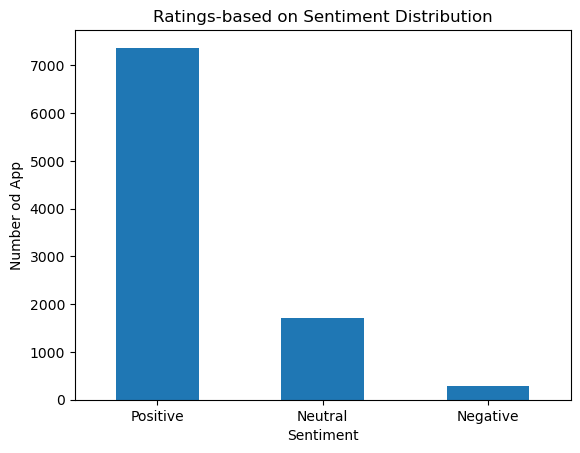

In [36]:
google_data['Sentiment'].value_counts().plot(
    kind='bar')
plt.title('Ratings-based on Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number od App')
plt.xticks(rotation=0)
plt.show()


In [43]:
sentiment_counts = google_data['Sentiment'].value_counts()

([<matplotlib.patches.Wedge at 0x219a372b390>,
 [Text(-0.6832392154421177, -0.8620813038699073, 'Positive'),
  Text(0.7629375325878328, 0.7924180218601731, 'Neutral'),
  Text(0.10573009176761083, 1.0949069127988977, 'Negative')],
 [Text(-0.3726759356957005, -0.47022616574722215, '79%'),
  Text(0.41614774504790875, 0.4322280119237307, '18%'),
  Text(0.057670959145969536, 0.5972219524357623, '3%')])

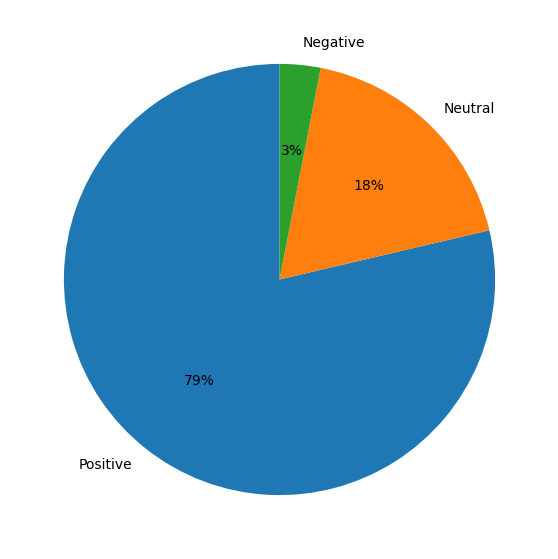

In [75]:
plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.f%%',
    startangle=90)
# The pie chart below clearly shows the distibution of positive ,negative, and neutral sentiments

In [46]:
google_data['Last Updated'].head()

0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
3        June 8, 2018
4       June 20, 2018
Name: Last Updated, dtype: object

In [47]:
google_data['Last Updated'].dtype

dtype('O')

In [74]:
# Above you can see the data is an object we will convert it o a proper date
google_data['Last Updated'] = pd.to_datetime(
    google_data['Last Updated'],
    errors='coerce')

In [66]:
google_data['Year'] =google_data['Last Updated'].dt.year

In [67]:
# Here we will be able to calculate the number of Positive, Nuetral, and Negative apps by year
sentiment_by_year = (
    google_data
    .groupby(['Year', 'Sentiment'])
    .size()
    .unstack(fill_value=0))


In [68]:
sentiment_by_year

Sentiment,Negative,Neutral,Positive
Year,,,
2010,0,0,1
2011,0,7,8
2012,1,8,12
2013,1,28,65
2014,7,55,128
2015,14,117,257
2016,31,190,430
2017,80,343,1075
2018,153,963,5392


In [69]:
import matplotlib.pyplot as plt

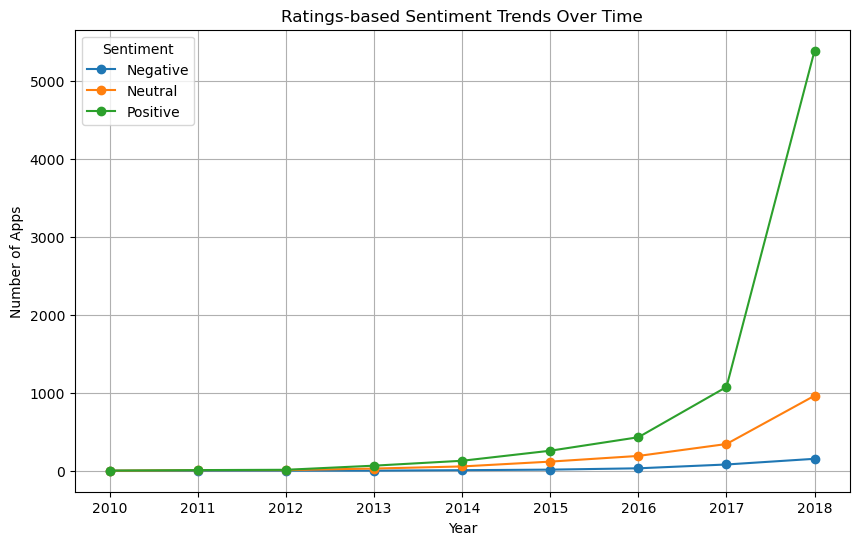

In [73]:
sentiment_by_year.plot(
    kind='line',
    marker = 'o',
    figsize=(10, 6)
)



plt.title('Ratings-based Sentiment Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Apps')
plt.grid(True)
plt.show()
# Here you can see the increase in 2010 --> 2018 5,392 apps           